In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [22]:
dataset1 = pd.read_csv('/content/drive/MyDrive/deep learning/ex1.sheet.csv')
X = dataset1[['X']].values
y = dataset1[['Y']].values

In [23]:
print(X)
print(y)

[[30]
 [40]
 [50]
 [34]
 [32]
 [43]
 [32]
 [61]
 [54]
 [23]
 [70]]
[[54]
 [76]
 [93]
 [48]
 [32]
 [64]
 [52]
 [86]
 [54]
 [21]
 [63]]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [25]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [27]:
# Name: Aman Alam
# Register Number: 212224240011
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1= nn.Linear(1,8)
        self.fc2= nn.Linear(8,10)
        self.fc3= nn.Linear(10,1)
        self.relu= nn.ReLU()
        self.history={'loss':[]}
  def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)
        return x






In [28]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
ai_brain=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(ai_brain.parameters(),lr=0.001)

In [29]:
# Name:Aman Alam
# Register Number:212224240011
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss= criterion(ai_brain(X_train),y_train)
        loss.backward()
        optimizer.step()



        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [30]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 4349.213379
Epoch [200/2000], Loss: 3326.580566
Epoch [400/2000], Loss: 1673.140015
Epoch [600/2000], Loss: 509.043610
Epoch [800/2000], Loss: 301.744781
Epoch [1000/2000], Loss: 279.903198
Epoch [1200/2000], Loss: 253.344833
Epoch [1400/2000], Loss: 235.141281
Epoch [1600/2000], Loss: 230.416748
Epoch [1800/2000], Loss: 228.625244


In [31]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 490.179413


In [32]:
loss_df = pd.DataFrame(ai_brain.history)

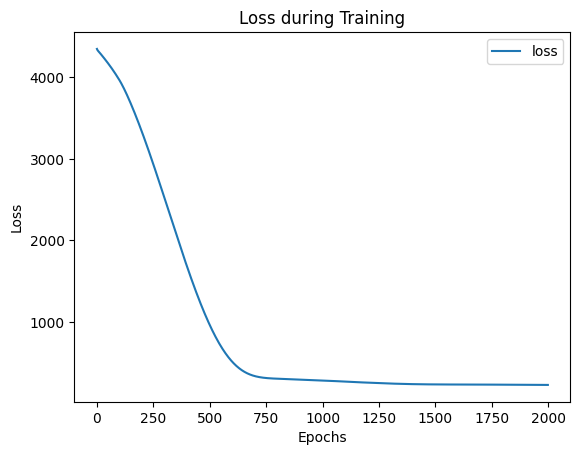

In [33]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [34]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 11.884224891662598
